First, read the execution trace from benchmark_result.pkl

In [32]:
import pickle
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, AsyncGenerator, Dict, List, Optional, Tuple, Union
import random
import matplotlib.pyplot as plt
import time
import numpy as np

@dataclass
class RequestFuncOutput:
    generated_text: str = ""
    success: bool = False
    latency: float = 0.0
    request_time: float = 0.0
    ttft: float = 0.0  # Time to first token
    itl: List[float] = field(default_factory=list)  # List of inter-token latencies
    prompt_len: int = 0
    error: str = ""
    output_len: int = 0
    output_speed: int = 40
    buffer_size: List[float] = field(default_factory=list)

# with open('exp_result/benchmark_result_custom_poisson300_rate5_1024_4096.pkl', 'rb') as f:
# with open('exp_result/benchmark_result_custom_poisson300_rate5.pkl', 'rb') as f:
with open('benchmark_result.pkl', 'rb') as f:
    outputs = pickle.load(f)

with open('exp_result/benchmark_result_baseline_poisson300_rate5.pkl', 'rb') as f:
    outputs_baseline = pickle.load(f)

with open('exp_result/benchmark_result_andes_poisson300_rate5_512_4096.pkl', 'rb') as f:
# with open('benchmark_result.pkl', 'rb') as f:
    outputs_andes = pickle.load(f)

total_time_baseline=146.08
for req in outputs_baseline:
    req.output_speed = 25

total_time=166.34 
for req in outputs:
    req.output_speed = 25

total_time_andes=187.96 

Calculate some meta information

In [162]:
output_speed = []
print(outputs[0].output_speed)
for output in outputs_baseline:
    output_speed.append(output.output_len / sum(output.itl))

print('Average Output Speed of Baseline:', sum(output_speed) / len(output_speed))
print('Min:', min(output_speed))
print('Max:', max(output_speed))

print('Baseline avg ttft:', sum([x.ttft for x in outputs_baseline]) / len(outputs_baseline))
print('Ours avg ttft:', sum([x.ttft for x in outputs]) / len(outputs))

25.0
Average Output Speed of Baseline: 43.33905279195714
Min: 9.942877675951571
Max: 86.50606147557885
Baseline avg ttft: 6.749073690207442
Ours avg ttft: 0.5831858122069389


Effective Throughput Calculation

In [33]:
from dataclasses import dataclass, field
from typing import List
import numpy as np


def compute_effective_throughput(requests: List[RequestFuncOutput],
                                 total_time: float,
                                 lambda_ttft: float = 0.0,
                                 mu_rebuffer: float = 30.0,
                                 sim_resolution: float = 0.01,  # seconds per sim step
                                 tau1: float = 0.1,
                                 tau2: float = 0.2,
                                 ) -> float:
    all_scores = []
    for i, req in enumerate(requests):
        itl = req.itl
        ttft = req.ttft
        output_speed = req.output_speed
        output_interval = 1.0 / output_speed

        token_timestamps = np.cumsum([ttft] + itl[:-1])
        sim_end = token_timestamps[-1] + 5.0  # simulate a bit beyond last token
        num_steps = int(sim_end / sim_resolution) + 1

        buffer_sizes = np.zeros(num_steps)
        rebuffer_time = 0.0
        buffer = 0
        current_token_idx = 0
        next_token_time = token_timestamps[0]
        next_read_time = req.ttft

        for step in range(num_steps):
            t = step * sim_resolution
            # Check if token arrives
            while current_token_idx < len(token_timestamps) and t >= token_timestamps[current_token_idx]:
                buffer += 1
                current_token_idx += 1
                if current_token_idx < len(token_timestamps):
                    next_token_time = token_timestamps[current_token_idx]
            # Check if user reads
            if t >= next_read_time:
                if buffer > 0:
                    buffer -= 1
                else:
                    rebuffer_time += sim_resolution
                next_read_time += output_interval

            buffer_sizes[step] = buffer
        
        # Weight for each token: linearly decay if buffer > tao
        usable_weights = []
        buffer_sizes = []
        buffer_virtual = 0
        for idx, t in enumerate(itl):
            buffer_virtual += 1
            buffer_virtual -= t * output_speed
            buffer_sizes.append(buffer_virtual)
            if buffer_virtual < 0: 
                weight = buffer_virtual
                buffer_virtual = 0
            else:
                # weight = 1.0 if buffer_virtual <= 3 else max(0.0, 1.0 - 0.2 * (buffer_virtual - 3))
                avg_output_len = 4096
                if buffer_virtual < avg_output_len * tau1:
                    weight = 1.0
                elif buffer_virtual > avg_output_len * tau2:
                    weight = 0.0
                else:
                    weight = 1.0 - (buffer_virtual - avg_output_len * tau1) / (avg_output_len * (tau2 - tau1))
            usable_weights.append(weight)
        # print(rebuffer_time, end=' ')
        score = sum(usable_weights) - lambda_ttft * ttft #- mu_rebuffer * rebuffer_time
        all_scores.append(score)

    return sum(all_scores) / total_time

et_score = compute_effective_throughput(outputs_baseline, total_time=total_time_baseline)
print(f"Effective Throughput Score: {et_score:.3f}")
et_score = compute_effective_throughput(outputs_andes, total_time=total_time_andes)
print(f"Effective Throughput Score: {et_score:.3f}")
et_score = compute_effective_throughput(outputs, total_time=total_time)
print(f"Effective Throughput Score: {et_score:.3f}")

Effective Throughput Score: 2381.927
Effective Throughput Score: 2159.171
Effective Throughput Score: 2788.469


Draw the graph of each request output tokens vs time

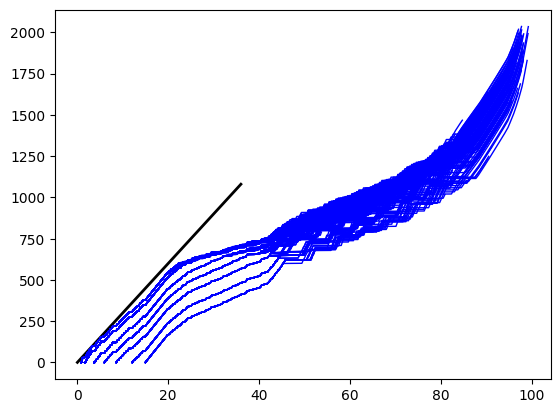

In [17]:
draw_target = outputs

output = draw_target[0]
cum_itl = [0] + np.cumsum(output.itl)

min_request_time = draw_target[0].request_time
for i in range(len(draw_target)):
    min_request_time = min(min_request_time, draw_target[i].request_time)

# reference lien of 20 token/s
plt.plot(cum_itl, [30 * (x) for x in cum_itl], label='20 token/sec', color='black', linewidth=2)

for i in range(len(draw_target)):
    output = draw_target[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        plt.plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='blue', linewidth=1)
    else:
        plt.plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=1)

Calculate and draw the line of buffer size

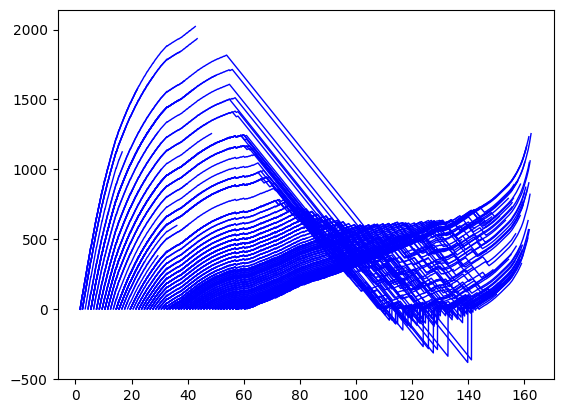

In [165]:
draw_target = outputs

output = draw_target[0]
cum_itl = [0] + np.cumsum(output.itl)
token_num = list(range(0, len(cum_itl)))
min_request_time = draw_target[0].request_time
for i in range(len(draw_target)):
    min_request_time = min(min_request_time, draw_target[i].request_time)

for i in range(len(draw_target)):
    output = draw_target[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    buffer_size = [0]
    for j in range(len(output.itl)):
        last_size = buffer_size[-1] if buffer_size[-1] >= 0 else 0
        last_size += 1
        last_size -= output.itl[j] * output.output_speed
        buffer_size.append(last_size)
    if output.output_speed < 30:
        plt.plot((output.request_time - min_request_time) + output.ttft + cum_itl, buffer_size[1:], color='blue', linewidth=1)
    else:
        plt.plot((output.request_time - min_request_time) + output.ttft + cum_itl, buffer_size[1:], color='red', linewidth=1)